In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

In [2]:
# Ensuring working directory is repo root
repo_root = os.path.expanduser("~/Desktop/UCD_Classes/STA141C/final_project")
os.chdir(repo_root)
print("CWD:", os.getcwd())
X_train = joblib.load("./data/processed/X_train.pkl")
X_test  = joblib.load("./data/processed/X_test.pkl")
y_train = joblib.load("./data/processed/y_train.pkl").astype(int)
y_test  = joblib.load("./data/processed/y_test.pkl").astype(int)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Default rate train:", y_train.mean(), "test:", y_test.mean())

logistic_model = joblib.load("./models/logistic_raw.joblib")
logistic_pca_model = joblib.load("./models/logistic_pca.joblib")
random_forest_model = joblib.load("./models/random_forest.joblib")

# Print type and parameters
print("logistic_model:", type(logistic_model))
print("\nlogistic_pca_model:", type(logistic_pca_model))
print("\nrandom_forest:", type(random_forest_model))

CWD: /Users/tuan/Desktop/UCD_Classes/STA141C/final_project
X_train: (24000, 23) X_test: (6000, 23)
Default rate train: 0.22004166666666666 test: 0.22583333333333333
logistic_model: <class 'sklearn.pipeline.Pipeline'>

logistic_pca_model: <class 'sklearn.pipeline.Pipeline'>

random_forest: <class 'sklearn.pipeline.Pipeline'>


In [12]:
def get_preds(model, X, threshold=0.4):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return pred, prob

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
models = {
    "Logistic (raw)": logistic_model,
    "Logistic + PCA": logistic_pca_model,
    "Random Forest": random_forest_model
}
rows = []
store = {}

for name, model in models.items():
    y_pred, y_prob = get_preds(model, X_test)
    m = compute_metrics(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    m["roc_auc"] = auc(fpr, tpr)
    rows.append({"model": name, **m})
    store[name] = {"y_pred": y_pred, "y_prob": y_prob, "fpr": fpr, "tpr": tpr}

metrics_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
metrics_df

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.810833,0.613169,0.439852,0.512248,0.769791
0,Logistic (raw),0.503833,0.285677,0.797786,0.420704,0.728170
1,Logistic + PCA,0.495000,0.282071,0.800000,0.417083,0.725878


In [22]:
# Get the feature names after they passed through the preprocessor
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

# Get the coefficients from the 'classifier' step
coefs = logistic_model.named_steps['classifier'].coef_[0]

# Create a sorted DataFrame
logistic_importance = pd.DataFrame({
    'Feature': feature_names, 
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 Risk Factors (Positive Coefficients):")
print(logistic_importance.head(5))

Top 5 Risk Factors (Positive Coefficients):
           Feature  Coefficient
2       num__PAY_0     0.578107
9   num__BILL_AMT2     0.297196
10  num__BILL_AMT3     0.126215
3       num__PAY_2     0.096994
4       num__PAY_3     0.075389


In [23]:
# Extract importances
rf_importances = random_forest_model.named_steps['classifier'].feature_importances_

# Map to feature names
rf_importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Important Features in Random Forest:")
print(rf_importance_df.head(5))


Top 5 Most Important Features in Random Forest:
          Feature  Importance
2      num__PAY_0    0.095970
1        num__AGE    0.063893
8  num__BILL_AMT1    0.063526
0  num__LIMIT_BAL    0.062791
9  num__BILL_AMT2    0.054761


In [24]:
pca_coefs = logistic_pca_model.named_steps['classifier'].coef_[0]

pca_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pca_coefs))],
    'Coefficient': pca_coefs
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic-PCA Coefficients:")
print(pca_df.head(5))


Logistic-PCA Coefficients:
   Component  Coefficient
1        PC2     0.358580
8        PC9     0.316977
11      PC12     0.279789
10      PC11     0.156078
3        PC4     0.135634


In [ ]:
pca_step = logistic_pca_model.named_steps['pca']
feature_names = logistic_pca_model.named_steps['preprocessor'].get_feature_names_out()

# Create the loadings DataFrame
loadings = pd.DataFrame(
    pca_step.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca_step.n_components_)],
    index=feature_names
)

# Display the top 5 components
top_5_loadings = loadings[[f'PC{i}' for i in range(1, 6)]]

# Print the features that contribute most to PC1 and PC2
print("Top features for PC1 (Sorted):")
print(top_5_loadings['PC1'].sort_values(ascending=False).head(5))

print("\nTop features for PC2 (Sorted):")
print(top_5_loadings['PC2'].sort_values(ascending=False).head(5))

Top features for PC1 (Sorted):
num__BILL_AMT4    0.354210
num__BILL_AMT5    0.352176
num__BILL_AMT3    0.351119
num__BILL_AMT2    0.346486
num__BILL_AMT6    0.344572
Name: PC1, dtype: float64

Top features for PC2 (Sorted):
num__PAY_4    0.347031
num__PAY_3    0.346916
num__PAY_2    0.338237
num__PAY_5    0.334286
num__PAY_6    0.308110
Name: PC2, dtype: float64


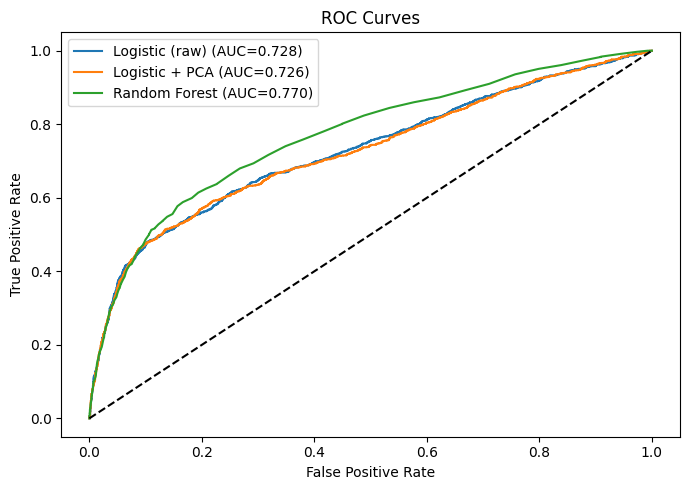

In [13]:
plt.figure(figsize=(7,5))
for name, d in store.items():
    roc_auc = auc(d["fpr"], d["tpr"])
    plt.plot(d["fpr"], d["tpr"], label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

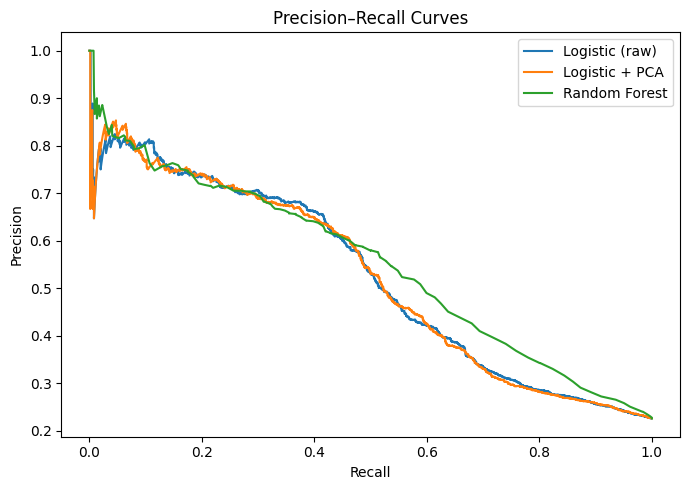

In [14]:
plt.figure(figsize=(7,5))
for name, d in store.items():
    prec, rec, _ = precision_recall_curve(y_test, d["y_prob"])
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

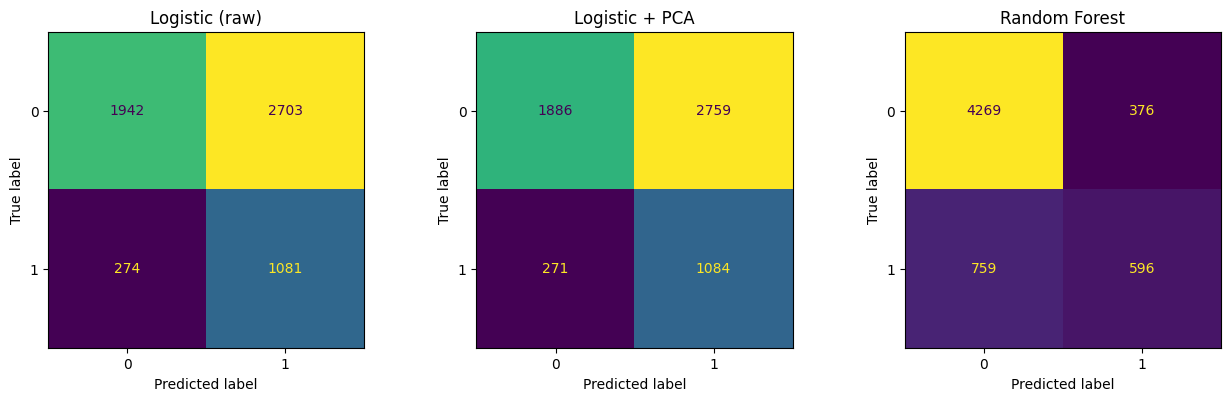

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, (name, d) in zip(axes, store.items()):
    cm = confusion_matrix(y_test, d["y_pred"])
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [7]:
# Cross validation

